In [1]:
import sys
import os

target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)

In [2]:
# Use helpers
from preprocess import * 
from understatapi import UnderstatClient

from preprocess.player_stats import get_position_players_stats_df

understat = UnderstatClient()

# Fit model to forwards for proof of concept
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
window_size = 10

f_stats = get_position_players_stats_df(understat, ['F'], stats)

In [3]:
# train/test split
train_len = int(len(f_stats) * 0.8)
train_df = f_stats.iloc[:train_len]
test_df = f_stats.iloc[train_len:]

In [4]:
from preprocess.player_stats import *

# create datasets
train_dataset = CustomFootballDataset(train_df, window_size, multiple_players=False)
test_dataset = CustomFootballDataset(test_df, window_size, multiple_players=False)

In [5]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [6]:
from football_lstm import *
import torch.optim as optim

model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=32)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 20

model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs
)

Train total loss: 3072.0278596282005
Test total loss: 1381.066788315773
Train total loss: 3057.0545010864735
Test total loss: 1379.9385035336018
Train total loss: 3128.658769249916
Test total loss: 1380.1414766609669
Train total loss: 3052.984023541212
Test total loss: 1379.1353453993797
Train total loss: 3050.713136047125
Test total loss: 1377.4939714372158
Train total loss: 3048.399466127157
Test total loss: 1375.93872448802
Train total loss: 3047.134100943804
Test total loss: 1375.6849393546581
Train total loss: 3048.0588032007217
Test total loss: 1377.3388233929873
Train total loss: 3042.5030732154846
Test total loss: 1377.1759220212698
Train total loss: 3076.516421496868
Test total loss: 1376.0860706865788
Train total loss: 3038.9000112116337
Test total loss: 1376.2965377569199
Train total loss: 3035.7250854969025
Test total loss: 1376.1256025135517
Train total loss: 3035.723018348217
Test total loss: 1377.228863477707
Train total loss: 3031.171131938696
Test total loss: 1375.5262

In [7]:
model.eval_model(test_dataloader)

Test RMSE: 3.346163511276245
Test MAE: 0.7906928658485413


RMSE: 0.7523810267448425
MAE: 0.5298125147819519
goals_per_90 RMSE: 1.3053195476531982
goals_per_90 MAE: 0.9595719575881958
xG_per_90 RMSE: 0.9293350577354431
xG_per_90 MAE: 0.6824929118156433
assists_per_90 RMSE: 0.546395480632782
assists_per_90 MAE: 0.2729349434375763
xA_per_90 RMSE: 0.30347076058387756
xA_per_90 MAE: 0.17872822284698486
key_passes_per_90 RMSE: 1.1054035425186157
key_passes_per_90 MAE: 0.850271463394165
xGChain_per_90 RMSE: 0.8357092142105103
xGChain_per_90 MAE: 0.6144793629646301
xGBuildup_per_90 RMSE: 0.24103380739688873
xGBuildup_per_90 MAE: 0.15020857751369476


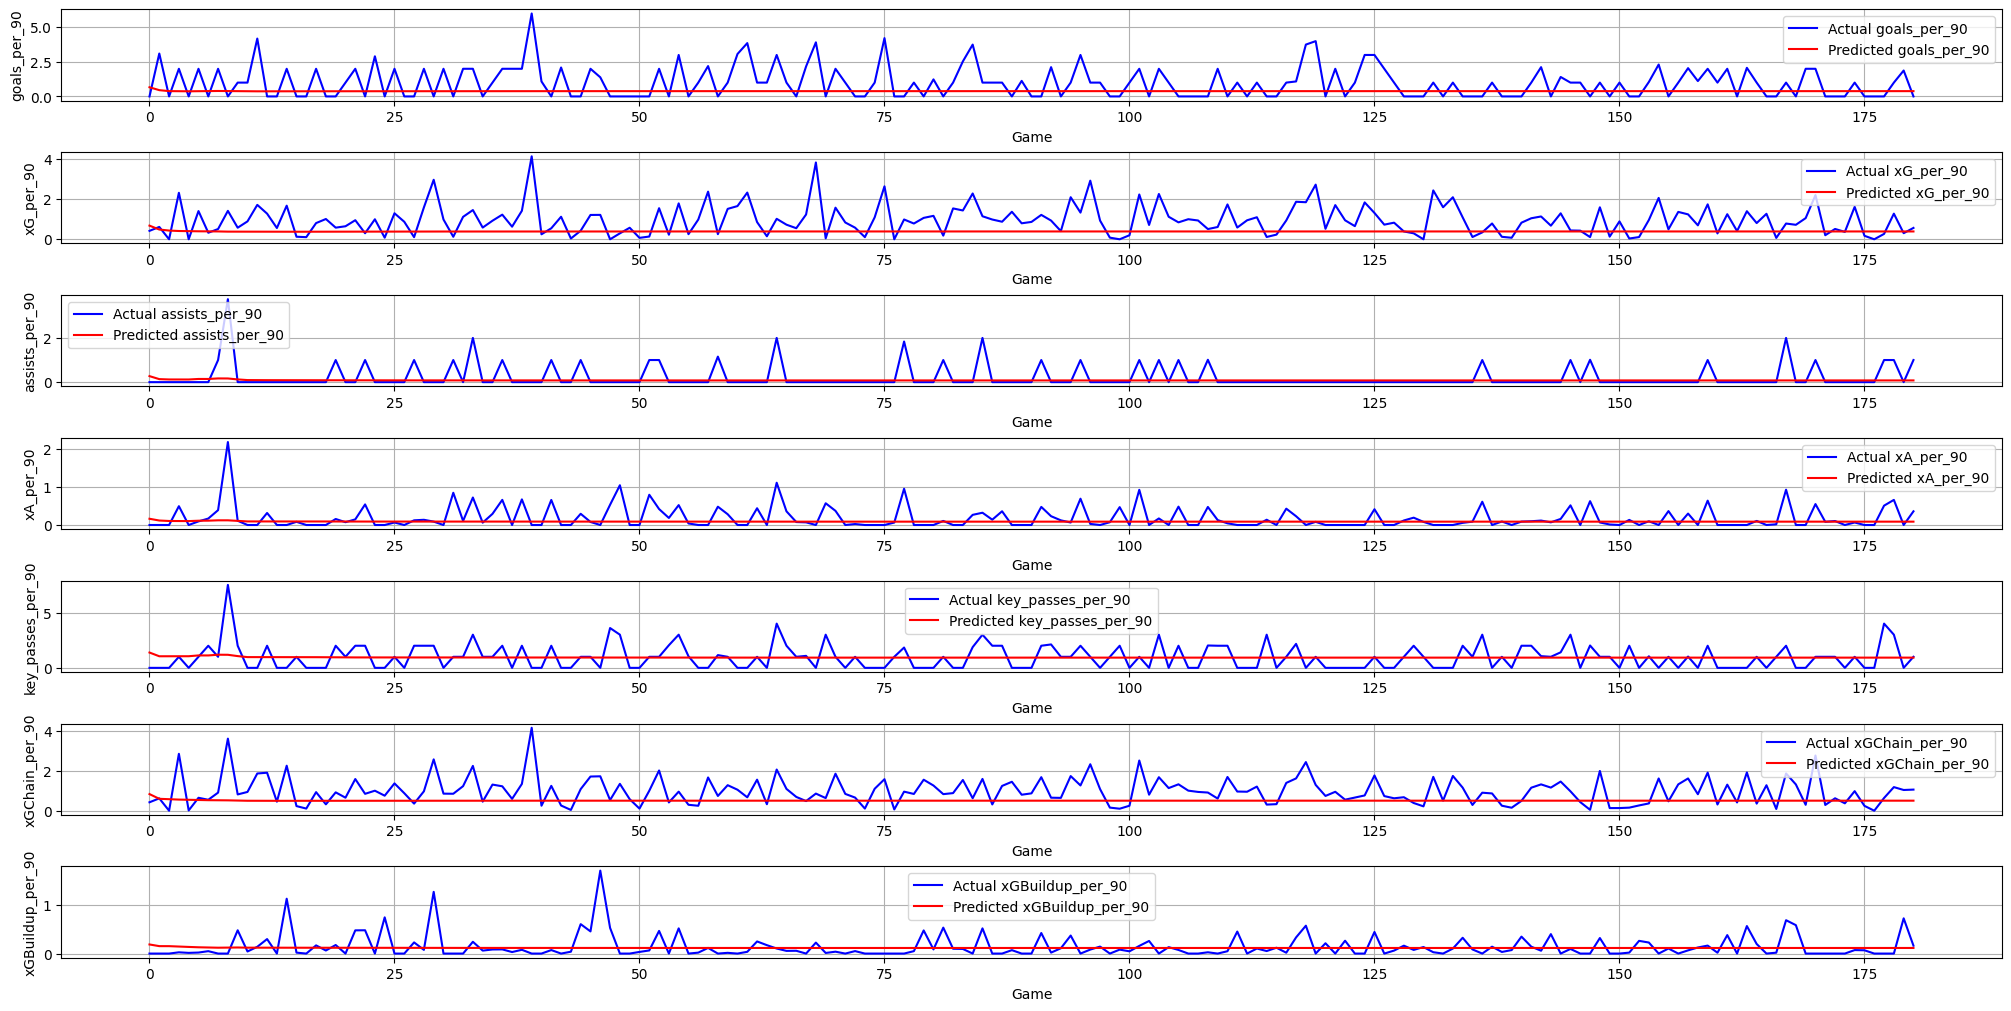

In [8]:
haaland_df = f_stats.loc["8260"]

model.eval_model_on_player(haaland_df)

In [9]:
x = torch.tensor(haaland_df.values[:window_size], dtype=torch.float32)
        
 # Have to unsqueeze to add batch dimension
x = x.unsqueeze(0)
y_trues = torch.tensor(haaland_df.values[window_size:], dtype=torch.float32)

y_preds = model.predict_next_k(x, len(haaland_df) - window_size).squeeze(0)

In [10]:
y_trues.shape
#y_preds.shape

torch.Size([181, 7])